# Exploratory Neural Networks

Neural-network experiments excluded from the submitted thesis. These cells depend on analysis objects from `main_file.ipynb` in the same kernel.


## Setup

In [5]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
import numpy as np
import pandas as pd
tf.get_logger().setLevel("ERROR")

from tensorflow import keras
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import TimeSeriesSplit
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import gc

## Features and Targets

In [6]:
data = factor_raw.copy().sort_index()
factors = data.columns.tolist()

# Inputs: median-relative current-month returns
# X_{i,t} = r_{i,t} - median_j(r_{j,t})
X_full_csfm = data.sub(data.median(axis=1), axis=0)

# Next-month realized returns
Y_next_raw = data.shift(-1)

# Binary classifier target:
# 1 if next-month factor return is above the next-month cross-sectional median
# 0 if below the next-month cross-sectional median
Y_full_csfm = Y_next_raw.gt(Y_next_raw.median(axis=1), axis=0).astype(float)

# Keep only complete rows
mask = X_full_csfm.notna().all(axis=1) & Y_next_raw.notna().all(axis=1)

X_full_csfm = X_full_csfm.loc[mask]
Y_full_csfm = Y_full_csfm.loc[mask]

print("X_full_csfm:", X_full_csfm.shape)
print("Y_full_csfm:", Y_full_csfm.shape)

print("Average fraction above median per month:")
print(Y_full_csfm.mean(axis=1).mean())

print("First date:", X_full_csfm.index.min())
print("Last date:", X_full_csfm.index.max())

X_full_csfm: (709, 48)
Y_full_csfm: (709, 48)
Average fraction above median per month:
0.5
First date: 1965-10-31 00:00:00
Last date: 2024-10-31 00:00:00


## Model and Walk-Forward Training

In [9]:
# Fixed training controls
FIXED_LR = 1e-3
FIXED_BATCH = 32

train_months_initial = 20 * 12
retrain_every = 5 * 12
predict_horizon = 5 * 12

expanding_train = True

cv_splits = 5
n_iter = 25


def build_model(
    meta,
    n_hidden=2,
    units_1=64,
    units_2=32,
    units_3=32,
    units_4=32,
    l2=1e-5,
    dropout=0.10,
    learning_rate=FIXED_LR,
):
    keras.backend.clear_session()
    gc.collect()

    n_features = meta["n_features_in_"]
    n_outputs = meta["n_outputs_"]

    layer_units = [
        units_1,
        units_2,
        units_3,
        units_4,
    ]

    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(n_features,)))

    for i in range(n_hidden):
        model.add(
            keras.layers.Dense(
                layer_units[i],
                activation="relu",
                kernel_regularizer=keras.regularizers.l2(l2)
            )
        )

        if dropout > 0:
            model.add(keras.layers.Dropout(dropout))

    model.add(keras.layers.Dense(n_outputs, activation="sigmoid"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["binary_accuracy"]
    )

    return model


search_space = {
    "model__n_hidden": Integer(1, 4),

    "model__units_1": Integer(32, 128),
    "model__units_2": Integer(16, 96),
    "model__units_3": Integer(16, 64),
    "model__units_4": Integer(16, 64),

    "model__l2": Real(1e-5, 1e-2, prior="log-uniform"),
    "model__dropout": Real(0.05, 0.35),

    "epochs": Integer(10, 50),
}

In [10]:
from tqdm.auto import tqdm

class TqdmBayesSearchCallback:
    def __init__(self, pbar):
        self.pbar = pbar

    def __call__(self, result):
        self.pbar.update(1)
        return False


def walkforward_multioutput_ffn_csfm_classifier(
    X_all,
    Y_all,
    factors,
    origin_start=0,
    origin_end=None,
    save_prefix="ml_files/ffn_csfm_classifier"
):
    """
    Multi-output FFN classifier for ML cross-sectional factor momentum.

    X_all:
        Input features, e.g. median-relative current factor returns:
            r_{i,t} - median_j(r_{j,t})

    Y_all:
        Binary next-month target:
            1 if r_{i,t+1} > median_j(r_{j,t+1})
            0 otherwise

    Returns:
        preds_wide_ffn_csfm_prob:
            Predicted probabilities:
                P(r_{i,t+1} > cross-sectional median at t+1)

        preds_long_dict_ffn_csfm:
            Per-factor long-form prediction dictionaries.

        best_params_ffn_csfm:
            Best hyperparameters by walk-forward origin.
    """

    n = len(X_all)

    if n <= train_months_initial:
        raise ValueError("Not enough observations for chosen train_months_initial.")

    all_origins = list(range(train_months_initial, n, retrain_every))

    if origin_end is None:
        origin_end = len(all_origins)

    origins = all_origins[origin_start:origin_end]

    print(f"Running origin slice {origin_start}:{origin_end}")
    print("Origins:", origins)
    print("Origin dates:", [X_all.index[o] for o in origins])

    pred_prob_blocks = []
    best_params_by_origin = []

    for origin in tqdm(origins, desc="Walk-forward origins", position=1, leave=True):
        train_start = 0 if expanding_train else max(0, origin - train_months_initial)
        train_end = origin
        test_start = origin
        test_end = min(origin + predict_horizon, n)

        X_train = X_all.iloc[train_start:train_end].copy()
        Y_train = Y_all.iloc[train_start:train_end].copy()
        X_test = X_all.iloc[test_start:test_end].copy()
        Y_test = Y_all.iloc[test_start:test_end].copy()

        # ------------------------------
        # Standardize X using training data only
        # ------------------------------
        x_mu = X_train.mean(axis=0)
        x_sd = X_train.std(axis=0).replace(0, 1.0)

        X_train_s = ((X_train - x_mu) / x_sd).fillna(0.0).to_numpy(dtype=np.float32)
        X_test_s = ((X_test - x_mu) / x_sd).fillna(0.0).to_numpy(dtype=np.float32)

        # ------------------------------
        # Classification target: keep as 0/1
        # Do NOT standardize Y.
        # ------------------------------
        Y_train_s = Y_train.fillna(0.0).to_numpy(dtype=np.float32)

        base_est = KerasRegressor(
            model=build_model,
            verbose=0,
            random_state=42,
            batch_size=FIXED_BATCH,
            model__learning_rate=FIXED_LR,
            fit__shuffle=False,
        )

        cv = TimeSeriesSplit(n_splits=cv_splits)

        opt = BayesSearchCV(
            estimator=base_est,
            search_spaces=search_space,
            n_iter=n_iter,

            # Brier-score-like objective for 0/1 labels and probability outputs.
            # This is robust for multi-output SciKeras.
            scoring="neg_mean_squared_error",

            cv=cv,
            n_jobs=1,
            random_state=42,
            verbose=0,
            refit=True
        )

        tqdm.write(f"Starting BayesSearchCV for origin={origin}")

        with tqdm(
            total=n_iter,
            desc=f"BayesSearch origin={origin}",
            position=0,
            leave=True
        ) as pbar:
            opt.fit(
                X_train_s,
                Y_train_s,
                callback=TqdmBayesSearchCallback(pbar)
            )

        # Predict probabilities
        Y_pred_prob = opt.best_estimator_.predict(X_test_s)

        Y_pred_prob = pd.DataFrame(
            Y_pred_prob,
            index=Y_test.index,
            columns=factors
        )

        pred_prob_blocks.append(Y_pred_prob)

        best_params_by_origin.append({
            "origin_idx": origin,
            "origin_date": X_all.index[origin],
            "best_params": opt.best_params_,
            "best_cv_brier_mse": -opt.best_score_,
            "train_start_idx": train_start,
            "train_end_idx": train_end - 1,
            "test_start_idx": test_start,
            "test_end_idx": test_end - 1,
        })

        tqdm.write(
            f"origin={origin}, "
            f"best_cv_brier_mse={-opt.best_score_:.8f}"
        )

        # Clean up
        del opt, base_est, cv
        del X_train, Y_train, X_test, Y_test
        del x_mu, x_sd
        del X_train_s, X_test_s, Y_train_s
        del Y_pred_prob

        keras.backend.clear_session()
        gc.collect()

    preds_wide_ffn_csfm_prob = (
        pd.concat(pred_prob_blocks)
        .sort_index()
        .reindex(Y_all.index)
    )

    best_params_ffn_csfm = pd.DataFrame(best_params_by_origin)

    preds_long_dict_ffn_csfm = {}

    for f in factors:
        tmp = pd.DataFrame({
            "y_true_class": Y_all[f].reindex(preds_wide_ffn_csfm_prob.index),
            "y_pred_prob": preds_wide_ffn_csfm_prob[f],
        }).dropna()

        preds_long_dict_ffn_csfm[f] = tmp

    preds_wide_ffn_csfm_prob.to_pickle(f"{save_prefix}_preds_prob_final.pkl")
    best_params_ffn_csfm.to_pickle(f"{save_prefix}_best_params_final.pkl")

    return (
        preds_wide_ffn_csfm_prob,
        preds_long_dict_ffn_csfm,
        best_params_ffn_csfm
    )

/home/kai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
preds_csfm_prob_part1, preds_long_csfm_part1, params_csfm_part1 = (
    walkforward_multioutput_ffn_csfm_classifier(
        X_full_csfm,
        Y_full_csfm,
        factors,
        origin_start=0,
        origin_end=4,
        save_prefix="ml_files/ffn_csfm_classifier_part1"
    )
)

Running origin slice 0:4
Origins: [240, 300, 360, 420]
Origin dates: [Timestamp('1985-10-31 00:00:00'), Timestamp('1990-10-31 00:00:00'), Timestamp('1995-10-31 00:00:00'), Timestamp('2000-10-31 00:00:00')]


Starting BayesSearchCV for origin=240


BayesSearch origin=240:   0%|          | 0/25 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1780436073.881995  214577 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21084 MB memory:  -> device: 0, name: AMD Radeon RX 7900 XTX, pci bus id: 0000:03:00.0
2026-06-02 23:34:35.608751: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attrib

origin=240, best_cv_brier_mse=0.24963098


Walk-forward origins:  25%|██▌       | 1/4 [05:57<17:53, 357.81s/it]
                                                                 

...

origin=360, best_cv_brier_mse=0.24901022


Starting BayesSearchCV for origin=420


BayesSearch origin=420:   0%|          | 0/25 [00:00<?, ?it/s]2026-06-02 23:59:15.429127: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-06-02 23:59:22.288847: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_argument

origin=420, best_cv_brier_mse=0.24925180


Walk-forward origins: 100%|██████████| 4/4 [37:17<00:00, 559.48s/it]


In [12]:
preds_csfm_prob_part2, preds_long_csfm_part2, params_csfm_part2 = (
    walkforward_multioutput_ffn_csfm_classifier(
        X_full_csfm,
        Y_full_csfm,
        factors,
        origin_start=4,
        origin_end=8,
        save_prefix="ml_files/ffn_csfm_classifier_part2"
    )
)

Running origin slice 4:8
Origins: [480, 540, 600, 660]
Origin dates: [Timestamp('2005-10-31 00:00:00'), Timestamp('2010-10-31 00:00:00'), Timestamp('2015-10-31 00:00:00'), Timestamp('2020-10-31 00:00:00')]


Starting BayesSearchCV for origin=480


BayesSearch origin=480:   0%|          | 0/25 [00:00<?, ?it/s]2026-06-03 00:12:08.198211: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-06-03 00:12:16.141991: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_argument

origin=480, best_cv_brier_mse=0.24937237


Starting BayesSearchCV for origin=540


...

Walk-forward origins:  75%|███████▌  | 3/4 [51:59<17:54, 1074.24s/it]
                                                                  

Starting BayesSearchCV for origin=660


BayesSearch origin=660:   0%|          | 0/25 [00:00<?, ?it/s]2026-06-03 01:04:10.622653: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-06-03 01:04:20.149001: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_argument

origin=660, best_cv_brier_mse=0.24950396


Walk-forward origins: 100%|██████████| 4/4 [1:13:58<00:00, 1109.73s/it]


## Saved Predictions

In [13]:
preds_csfm_prob_parts = [
    pd.read_pickle("ml_files/ffn_csfm_classifier_part1_preds_prob_final.pkl"),
    pd.read_pickle("ml_files/ffn_csfm_classifier_part2_preds_prob_final.pkl"),
    # pd.read_pickle("ml_files/ffn_csfm_classifier_part3_preds_prob_final.pkl"),
]

params_csfm_parts = [
    pd.read_pickle("ml_files/ffn_csfm_classifier_part1_best_params_final.pkl"),
    pd.read_pickle("ml_files/ffn_csfm_classifier_part2_best_params_final.pkl"),
    # pd.read_pickle("ml_files/ffn_csfm_classifier_part3_best_params_final.pkl"),
]


def combine_reindexed_prediction_parts(parts, target_index, keep="last"):
    """
    Each saved part has already been reindexed to the full target index.
    Therefore, before concatenating, drop rows that are all NaN.
    Then concatenate actual prediction rows only.
    """

    cleaned_parts = []

    for i, part in enumerate(parts, start=1):
        part_clean = part.dropna(how="all").copy()

        print(f"Part {i}:")
        print("  original shape:", part.shape)
        print("  non-null rows shape:", part_clean.shape)
        print("  non-null start:", part_clean.index.min())
        print("  non-null end:", part_clean.index.max())
        print()

        cleaned_parts.append(part_clean)

    combined = pd.concat(cleaned_parts).sort_index()

    # Check for overlapping prediction months after dropping all-NaN rows
    n_dup = combined.index.duplicated(keep=False).sum()

    if n_dup > 0:
        print(f"Found {n_dup} duplicated non-null prediction rows. Keeping '{keep}' occurrence.")
        duplicated_dates = combined.index[combined.index.duplicated(keep=False)].unique()
        print("First duplicated dates:")
        print(duplicated_dates[:10])

        combined = combined.loc[~combined.index.duplicated(keep=keep)]

    combined = combined.sort_index()

    # Reindex back to full target index after duplicates are removed
    combined = combined.reindex(target_index)

    return combined


preds_wide_ffn_csfm_prob = combine_reindexed_prediction_parts(
    preds_csfm_prob_parts,
    target_index=Y_full_csfm.index,
    keep="last"
)

best_params_ffn_csfm = pd.concat(params_csfm_parts, ignore_index=True)

preds_long_dict_ffn_csfm = {}

for f in factors:
    tmp = pd.DataFrame({
        "y_true_class": Y_full_csfm[f].reindex(preds_wide_ffn_csfm_prob.index),
        "y_pred_prob": preds_wide_ffn_csfm_prob[f],
    }).dropna()

    preds_long_dict_ffn_csfm[f] = tmp

print("Combined preds_wide_ffn_csfm_prob:", preds_wide_ffn_csfm_prob.shape)
print("Non-null probability rows:", preds_wide_ffn_csfm_prob.dropna(how="all").shape[0])

display(best_params_ffn_csfm)

Part 1:
  original shape: (709, 48)
  non-null rows shape: (240, 48)
  non-null start: 1985-10-31 00:00:00
  non-null end: 2005-09-30 00:00:00

Part 2:
  original shape: (709, 48)
  non-null rows shape: (229, 48)
  non-null start: 2005-10-31 00:00:00
  non-null end: 2024-10-31 00:00:00

Combined preds_wide_ffn_csfm_prob: (709, 48)
Non-null probability rows: 469


,origin_idx,origin_date,best_params,best_cv_brier_mse,train_start_idx,train_end_idx,test_start_idx,test_end_idx
0,240,1985-10-31,"{'epochs': 22, 'model__dropout': 0.10214478552...",0.249631,0,239,240,299
1,300,1990-10-31,"{'epochs': 26, 'model__dropout': 0.26831772295...",0.248634,0,299,300,359
2,360,1995-10-31,"{'epochs': 26, 'model__dropout': 0.26831772295...",0.249010,0,359,360,419
3,420,2000-10-31,"{'epochs': 19, 'model__dropout': 0.28937082244...",0.249252,0,419,420,479
4,480,2005-10-31,"{'epochs': 18, 'model__dropout': 0.35, 'model_...",0.249372,0,479,480,539
5,540,2010-10-31,"{'epochs': 10, 'model__dropout': 0.16279146081...",0.249767,0,539,540,599
6,600,2015-10-31,"{'epochs': 26, 'model__dropout': 0.26831772295...",0.248889,0,599,600,659
7,660,2020-10-31,"{'epochs': 10, 'model__dropout': 0.30302373137...",0.249504,0,659,660,708


In [22]:
best_params_ffn_csfm["best_params"][4]

OrderedDict([('epochs', 32),
             ('model__base_units', 32),
             ('model__dropout', 0.35),
             ('model__l2', 0.01),
             ('model__n_hidden', 3),
             ('model__shrink_factor', 0.5)])

## Portfolio Comparisons

In [14]:
def build_quantile_csfm_from_sorting_variable(
    sorting_variable,
    actual_rets,
    name,
    q=0.30,
    shift_signal=True
):
    sorting_variable = sorting_variable.copy().sort_index()
    actual_rets = actual_rets.copy().sort_index()

    if shift_signal:
        signal = sorting_variable.shift(1).reindex_like(actual_rets)
    else:
        signal = sorting_variable.reindex_like(actual_rets)

    low_cut = signal.quantile(q, axis=1)
    high_cut = signal.quantile(1 - q, axis=1)

    long_mask = signal.ge(high_cut, axis=0)
    short_mask = signal.le(low_cut, axis=0)

    long_ret = actual_rets.where(long_mask).mean(axis=1, skipna=True)
    short_ret = actual_rets.where(short_mask).mean(axis=1, skipna=True)

    return (long_ret - short_ret).rename(name)

In [28]:
for q in [0.10, 0.20, 0.30, 0.40, 0.50]:
    nn_q = build_quantile_csfm_from_sorting_variable(
        nn_prob,
        actual_rets,
        f"NN_q{q}",
        q=q,
        shift_signal=True
    )
    print(q, ann_summary(nn_q.loc[csfm_returns_sample.index], f"NN_q{q}"))

0.1 {'Strategy': 'NN_q0.1', 'T': 468, 'E[r]_ann': 0.07996595535930022, 'Vol_ann': np.float64(0.116602137068808), 'Sharpe_ann': np.float64(0.6858017989165289), 'skew': 0.13273537939522395, 'kurtosis_excess': 2.7797698051311603, 'min_monthly': -0.13216539402814204, 'max_monthly': 0.14138822489038477}
0.2 {'Strategy': 'NN_q0.2', 'T': 468, 'E[r]_ann': 0.07135343623737114, 'Vol_ann': np.float64(0.10463668354398294), 'Sharpe_ann': np.float64(0.6819160720759891), 'skew': 0.18243331000171153, 'kurtosis_excess': 3.715788349198657, 'min_monthly': -0.16519917481442892, 'max_monthly': 0.11867166575547616}
0.3 {'Strategy': 'NN_q0.3', 'T': 468, 'E[r]_ann': 0.052070408885188754, 'Vol_ann': np.float64(0.09160536329567835), 'Sharpe_ann': np.float64(0.5684209637062295), 'skew': 0.010484100949551886, 'kurtosis_excess': 3.889058672878391, 'min_monthly': -0.14666271045658247, 'max_monthly': 0.10510878578613753}
0.4 {'Strategy': 'NN_q0.4', 'T': 468, 'E[r]_ann': 0.04860485511523058, 'Vol_ann': np.float64(0.0

CSFM comparison start date: 1985-11-30 00:00:00
CSFM comparison end date: 2024-10-31 00:00:00
Number of months: 468


/tmp/ipykernel_214577/4154128767.py:136: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  ensemble_preds = concat.groupby(level=1, axis=1).mean()


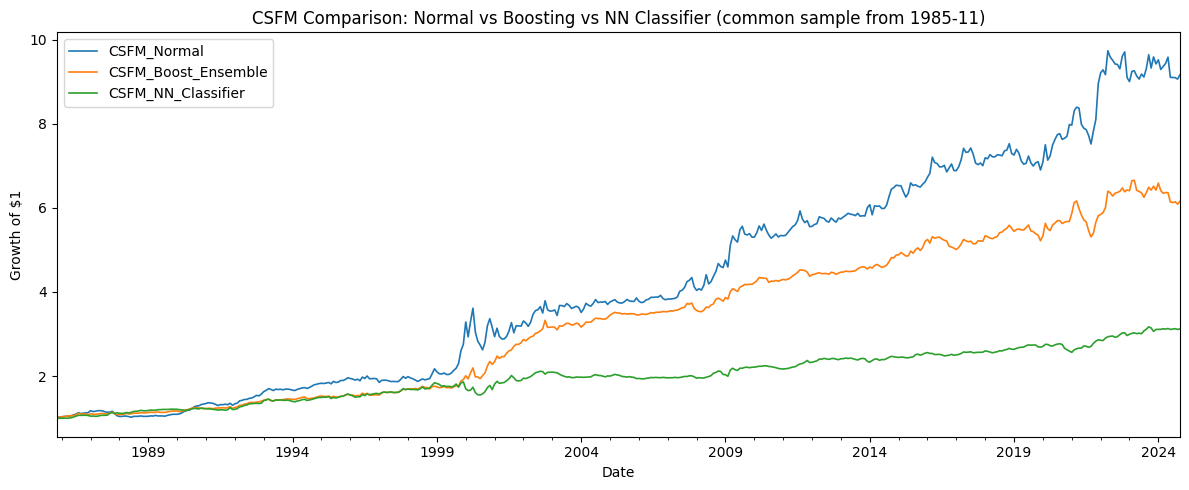

,T,E[r]_ann,Vol_ann,Sharpe_ann,skew,kurtosis_excess,min_monthly,max_monthly
Strategy,,,,,,,,
CSFM_Normal,468,0.0619,0.1005,0.6158,0.7988,8.5051,-0.1585,0.1931
CSFM_Boost_Ensemble,468,0.0483,0.0577,0.8380,0.2689,5.2889,-0.0959,0.0800
CSFM_NN_Classifier,468,0.0306,0.0521,0.5870,-0.1099,7.1499,-0.0879,0.0773


,CSFM_Normal_n_long,CSFM_Normal_n_short,CSFM_Boost_Ensemble_n_long,CSFM_Boost_Ensemble_n_short,CSFM_NN_Classifier_n_long,CSFM_NN_Classifier_n_short
count,468.0,468.0,468.0,468.0,468.0,468.0
mean,24.0,24.0,24.0,24.0,24.0,24.0
std,0.0,0.0,0.0,0.0,0.0,0.0
min,24.0,24.0,24.0,24.0,24.0,24.0
25%,24.0,24.0,24.0,24.0,24.0,24.0
50%,24.0,24.0,24.0,24.0,24.0,24.0
75%,24.0,24.0,24.0,24.0,24.0,24.0
max,24.0,24.0,24.0,24.0,24.0,24.0


,nn_prob_mean,nn_prob_std,nn_prob_min,nn_prob_max
count,468.0000,468.0000,468.0000,468.0000
mean,0.5003,0.0399,0.4169,0.5828
std,0.0010,0.0192,0.0359,0.0362
min,0.4986,0.0208,0.2217,0.5425
25%,0.4994,0.0266,0.3908,0.5605
50%,0.5003,0.0355,0.4297,0.5791
75%,0.5008,0.0455,0.4424,0.5969
max,0.5074,0.1547,0.4555,0.7898


,Normal_CSFM_hit_rate,Boost_CSFM_hit_rate,NN_CSFM_hit_rate
count,468.0000,468.0000,468.0000
mean,0.5438,0.5354,0.5278
std,0.1942,0.1264,0.1173
min,0.0833,0.2083,0.2083
25%,0.4167,0.4583,0.4583
50%,0.5417,0.5417,0.5417
75%,0.6771,0.6250,0.6250
max,0.9583,0.9167,0.7917


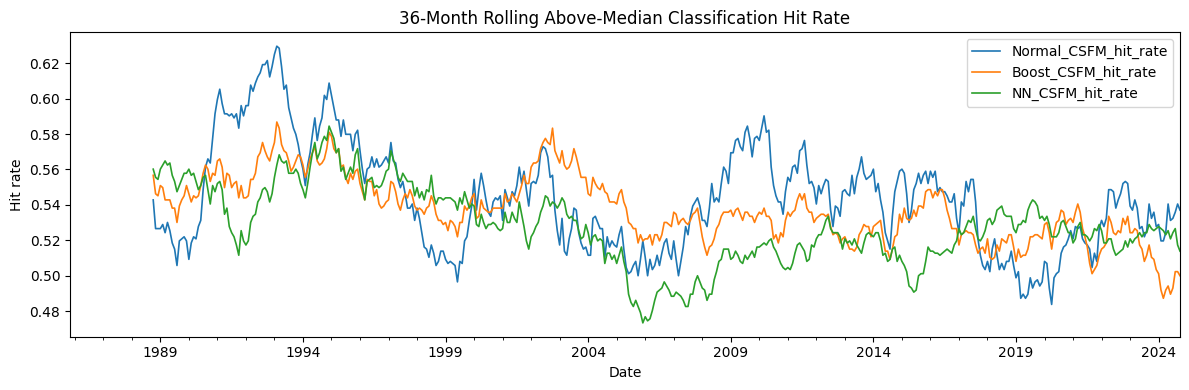

In [15]:
# ============================================================
# CSFM COMPARISON:
# Normal CSFM vs Boosting CSFM vs NN Classifier CSFM
# ============================================================
# Portfolio rule:
#   Long factors with sorting variable above cross-sectional median.
#   Short factors with sorting variable below cross-sectional median.
#   Long and short legs are equal-weighted separately.
#
# Sorting variables:
#   1. Normal CSFM: previous realized factor return
#   2. Boosting CSFM: ensemble boosting predicted raw return
#   3. NN CSFM classifier: predicted probability of above-median return
# ============================================================

actual_rets = factor_raw.copy().sort_index()
factors = actual_rets.columns.tolist()


# ------------------------------------------------------------
# Helper: equal-weight above/below median CSFM construction
# ------------------------------------------------------------

def build_ew_csfm_from_sorting_variable(
    sorting_variable,
    actual_rets,
    name,
    shift_signal=True
):
    """
    Equal-weight cross-sectional factor momentum portfolio.

    sorting_variable:
        DataFrame indexed by signal/prediction month, columns = factors.
        Higher value means more attractive.

    actual_rets:
        DataFrame of realized factor returns, indexed by return month.

    name:
        Name of output return series.

    shift_signal:
        If True, signal at t is applied to return at t+1.
        This should be True for:
            - previous realized returns
            - boosting predictions made at t for t+1
            - NN probabilities made at t for t+1

    Portfolio:
        Long factors above the cross-sectional median of the sorting variable.
        Short factors below the cross-sectional median.
        Equal-weight long leg and equal-weight short leg.
    """

    sorting_variable = sorting_variable.copy().sort_index()
    actual_rets = actual_rets.copy().sort_index()

    if shift_signal:
        signal = sorting_variable.shift(1).reindex_like(actual_rets)
    else:
        signal = sorting_variable.reindex_like(actual_rets)

    cs_median = signal.median(axis=1)

    long_mask = signal.gt(cs_median, axis=0)
    short_mask = signal.lt(cs_median, axis=0)

    long_ret = actual_rets.where(long_mask).mean(axis=1, skipna=True)
    short_ret = actual_rets.where(short_mask).mean(axis=1, skipna=True)

    ls_ret = (long_ret - short_ret).rename(name)

    diagnostics = pd.DataFrame({
        f"{name}_n_long": long_mask.sum(axis=1),
        f"{name}_n_short": short_mask.sum(axis=1),
        f"{name}_long_ret": long_ret,
        f"{name}_short_ret": short_ret,
    })

    return ls_ret, diagnostics


def ann_summary(returns, name):
    ser = returns.dropna()
    T = len(ser)

    mu_m = float(ser.mean()) if T > 0 else np.nan
    sd_m = float(ser.std(ddof=1)) if T > 1 else np.nan
    sr_m = mu_m / sd_m if T > 1 and sd_m > 0 else np.nan

    return {
        "Strategy": name,
        "T": T,
        "E[r]_ann": 12.0 * mu_m if T > 0 else np.nan,
        "Vol_ann": np.sqrt(12.0) * sd_m if T > 1 else np.nan,
        "Sharpe_ann": np.sqrt(12.0) * sr_m if not np.isnan(sr_m) else np.nan,
        "skew": float(ser.skew()) if T > 0 else np.nan,
        "kurtosis_excess": float(ser.kurtosis()) if T > 0 else np.nan,
        "min_monthly": float(ser.min()) if T > 0 else np.nan,
        "max_monthly": float(ser.max()) if T > 0 else np.nan,
    }


# ------------------------------------------------------------
# 1) Normal CSFM
# ------------------------------------------------------------
# Sorting variable at t is realized factor return at t.
# Because build_ew_csfm_from_sorting_variable shifts by 1,
# the portfolio at return month t uses factor returns from t-1.

csfm_normal_ret, diag_normal = build_ew_csfm_from_sorting_variable(
    sorting_variable=actual_rets,
    actual_rets=actual_rets,
    name="CSFM_Normal",
    shift_signal=True
)


# ------------------------------------------------------------
# 2) Boosting CSFM: build ensemble raw-return predictions
# ------------------------------------------------------------

models = {
    "XGB_fixed": preds_wide_fixed_xgb,
    "XGB_expanding": preds_wide_expanding_xgb,
    "LGB_fixed": preds_wide_fixed_lgb,
    "LGB_expanding": preds_wide_expanding_lgb,
    "CB_fixed": preds_wide_fixed_cb,
    "CB_expanding": preds_wide_expanding_cb,
}

concat = pd.concat(models.values(), keys=models.keys(), axis=1)

# MultiIndex columns: (model, factor)
ensemble_preds = concat.groupby(level=1, axis=1).mean()
ensemble_preds = ensemble_preds.reindex(columns=factors).sort_index()

csfm_boost_ret, diag_boost = build_ew_csfm_from_sorting_variable(
    sorting_variable=ensemble_preds,
    actual_rets=actual_rets,
    name="CSFM_Boost_Ensemble",
    shift_signal=True
)


# ------------------------------------------------------------
# 3) NN CSFM classifier
# ------------------------------------------------------------
# preds_wide_ffn_csfm_prob should contain:
# P(r_{i,t+1} > median_j(r_{j,t+1}))
#
# Higher probability = more attractive.
# Portfolio longs probabilities above cross-sectional median,
# shorts probabilities below cross-sectional median.

nn_prob = (
    preds_wide_ffn_csfm_prob
    .copy()
    .reindex(columns=factors)
    .sort_index()
)

csfm_nn_ret, diag_nn = build_ew_csfm_from_sorting_variable(
    sorting_variable=nn_prob,
    actual_rets=actual_rets,
    name="CSFM_NN_Classifier",
    shift_signal=True
)


# ------------------------------------------------------------
# 4) Collect return series
# ------------------------------------------------------------

csfm_returns = pd.concat(
    [
        csfm_normal_ret,
        csfm_boost_ret,
        csfm_nn_ret,
    ],
    axis=1
)


# ------------------------------------------------------------
# 5) Restrict to common comparison sample
# ------------------------------------------------------------
# Normal CSFM starts much earlier, so restrict all strategies to the first
# date where the ML strategies are available.

ml_start_candidates = [
    csfm_boost_ret.dropna().index.min(),
    csfm_nn_ret.dropna().index.min(),
]

start_date = max([d for d in ml_start_candidates if pd.notna(d)])

csfm_returns_sample = csfm_returns.loc[start_date:].copy()

# Use exactly the same months for all strategies.
csfm_returns_sample = csfm_returns_sample.dropna(how="any")

if csfm_returns_sample.empty:
    raise RuntimeError(
        "Common CSFM comparison sample is empty. "
        "Check overlap between normal CSFM, boosting predictions, and NN predictions."
    )

print("CSFM comparison start date:", csfm_returns_sample.index.min())
print("CSFM comparison end date:", csfm_returns_sample.index.max())
print("Number of months:", len(csfm_returns_sample))


# ------------------------------------------------------------
# 6) Plot cumulative returns
# ------------------------------------------------------------

ax = (1 + csfm_returns_sample).cumprod().plot(
    figsize=(12, 5),
    linewidth=1.2
)

ax.set_title(
    f"CSFM Comparison: Normal vs Boosting vs NN Classifier "
    f"(common sample from {csfm_returns_sample.index.min().strftime('%Y-%m')})"
)
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7) Summary statistics
# ------------------------------------------------------------

summary_rows = []

for col in csfm_returns_sample.columns:
    summary_rows.append(
        ann_summary(csfm_returns_sample[col], col)
    )

summary_csfm = pd.DataFrame(summary_rows).set_index("Strategy")

display(summary_csfm.round(4))


# ------------------------------------------------------------
# 8) Long/short count diagnostics
# ------------------------------------------------------------

diag_all = pd.concat(
    [
        diag_normal,
        diag_boost,
        diag_nn,
    ],
    axis=1
)

diag_sample = diag_all.loc[csfm_returns_sample.index].copy()

count_cols = [c for c in diag_sample.columns if c.endswith("_n_long") or c.endswith("_n_short")]

display(diag_sample[count_cols].describe().round(2))


# ------------------------------------------------------------
# 9) Optional: classifier diagnostics
# ------------------------------------------------------------

# Predicted probability dispersion by month
nn_prob_aligned = nn_prob.shift(1).reindex_like(actual_rets)

nn_prob_diag = pd.DataFrame({
    "nn_prob_mean": nn_prob_aligned.mean(axis=1),
    "nn_prob_std": nn_prob_aligned.std(axis=1),
    "nn_prob_min": nn_prob_aligned.min(axis=1),
    "nn_prob_max": nn_prob_aligned.max(axis=1),
})

nn_prob_diag_sample = nn_prob_diag.loc[csfm_returns_sample.index].copy()

display(nn_prob_diag_sample.describe().round(4))


# ------------------------------------------------------------
# 10) Optional: above-median classification accuracy
# ------------------------------------------------------------
# At return month t, compare predicted top half at t-1 to actual above-median labels at t.

actual_above_median = actual_rets.gt(actual_rets.median(axis=1), axis=0)

nn_signal_aligned = nn_prob.shift(1).reindex_like(actual_rets)
nn_pred_above_median = nn_signal_aligned.gt(nn_signal_aligned.median(axis=1), axis=0)

boost_signal_aligned = ensemble_preds.shift(1).reindex_like(actual_rets)
boost_pred_above_median = boost_signal_aligned.gt(boost_signal_aligned.median(axis=1), axis=0)

normal_signal_aligned = actual_rets.shift(1).reindex_like(actual_rets)
normal_pred_above_median = normal_signal_aligned.gt(normal_signal_aligned.median(axis=1), axis=0)

classification_accuracy = pd.DataFrame({
    "Normal_CSFM_hit_rate": (
        normal_pred_above_median.eq(actual_above_median)
        .mean(axis=1)
    ),
    "Boost_CSFM_hit_rate": (
        boost_pred_above_median.eq(actual_above_median)
        .mean(axis=1)
    ),
    "NN_CSFM_hit_rate": (
        nn_pred_above_median.eq(actual_above_median)
        .mean(axis=1)
    ),
})

classification_accuracy_sample = (
    classification_accuracy
    .loc[csfm_returns_sample.index]
    .dropna(how="any")
)

display(classification_accuracy_sample.describe().round(4))

ax = classification_accuracy_sample.rolling(36).mean().plot(
    figsize=(12, 4),
    linewidth=1.2
)

ax.set_title("36-Month Rolling Above-Median Classification Hit Rate")
ax.set_xlabel("Date")
ax.set_ylabel("Hit rate")

plt.tight_layout()
plt.show()